In [14]:
# =============================================================================
# Zelle 01 – Setup & Daten laden
# =============================================================================
# Notebook 05: Modelltraining Modell A (AP 3.4). Ablationsstudie ueber
# Feature-Sets x Modelltypen x Zielgroessen-Varianten.
# =============================================================================

import sys
sys.path.append('../src')

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from viz_config_v2 import apply_store44_style, save_figure, COLOR_GOLD, COLOR_BLUE, COLOR_GREEN, COLOR_TEXT_MUTED, BOXPLOT_STYLE
from preprocessing import load_dataset, select_dataset, get_target, get_feature_set, FEATURE_SETS, TARGET_VARIANTS, DNResidualizer, NUMERISCHE_BASIS_SPALTEN, KATEGORIALE_SPALTEN

SEED = 42
apply_store44_style()

df = load_dataset("../data/processed/model_a_preprocessed.csv")

print(f"pandas-Version: {pd.__version__}")
print(f"Datensatz geladen: {df.shape}")
print(f"io_nio-Verteilung: {df['io_nio'].value_counts().to_dict()}")
print(f"Erste Zeile Kontrollwerte: schneckendrehzahl={df['schneckendrehzahl'].iloc[0]:.3f}, io_nio={df['io_nio'].iloc[0]}")
print(f"Verfuegbare Feature-Sets: {list(FEATURE_SETS.keys())}")
print(f"Verfuegbare Zielgroessen-Varianten: {list(TARGET_VARIANTS.keys())}")

pandas-Version: 2.2.3
Datensatz geladen: (700, 44)
io_nio-Verteilung: {'IO': 517, 'NIO': 183}
Erste Zeile Kontrollwerte: schneckendrehzahl=41.063, io_nio=NIO
Verfuegbare Feature-Sets: ['original', 'original_no_kategorial', 'residual', 'combined']
Verfuegbare Zielgroessen-Varianten: ['binary', 'continuous', 'multilabel']


In [3]:
# =============================================================================
# Zelle 02 – Train/Test-Split (einmalig fixiert, fuer alle Kombinationen)
# =============================================================================
# Ein einziger Split ueber alle 700 Indizes, konsistent fuer alle
# Feature-Sets und Zielgroessen-Varianten verwendet (Vergleichbarkeit).
# Stratifizierung auf io_nio (binaeres Label), da dies das gemeinsame
# Bezugslabel fuer alle drei Zielgroessen-Varianten ist.
# =============================================================================

from sklearn.model_selection import train_test_split

train_idx, test_idx = train_test_split(
    df.index, test_size=0.2, stratify=df["io_nio"], random_state=SEED
)

print(f"Train: {len(train_idx)} Zeilen, Test: {len(test_idx)} Zeilen")
print(f"\nIO/NIO-Verteilung Train:\n{df.loc[train_idx, 'io_nio'].value_counts(normalize=True).round(3)}")
print(f"\nIO/NIO-Verteilung Test:\n{df.loc[test_idx, 'io_nio'].value_counts(normalize=True).round(3)}")

Train: 560 Zeilen, Test: 140 Zeilen

IO/NIO-Verteilung Train:
io_nio
IO     0.739
NIO    0.261
Name: proportion, dtype: float64

IO/NIO-Verteilung Test:
io_nio
IO     0.736
NIO    0.264
Name: proportion, dtype: float64


In [4]:
# =============================================================================
# Zelle 03 – Modell-Registry (konservative Standard-Hyperparameter)
# =============================================================================
# Kein Tuning in diesem AP - Standardwerte mit Begruendung je Modell,
# siehe Diskussion. random_state=SEED durchgaengig fuer Reproduzierbarkeit.
# =============================================================================

from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.svm import SVC, SVR
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.multioutput import MultiOutputClassifier
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor

MODELLE_BINAER = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=SEED),
    "kNN": KNeighborsClassifier(n_neighbors=5),
    "SVC": SVC(C=1.0, kernel="rbf", random_state=SEED),
    "RandomForest": RandomForestClassifier(n_estimators=200, max_depth=8, min_samples_leaf=3, random_state=SEED),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        max_iter=50, max_depth=3, max_leaf_nodes=15, min_samples_leaf=20, l2_regularization=1.0, random_state=SEED),
    "XGBoost": XGBClassifier(
        n_estimators=50, max_depth=3, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8,
        reg_lambda=2.0, random_state=SEED, eval_metric="logloss"),
    "LightGBM": LGBMClassifier(
        n_estimators=50, num_leaves=7, max_depth=3, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8,
        min_child_samples=30, random_state=SEED, verbose=-1),
    "GaussianNB": GaussianNB(),
    "MLP": MLPClassifier(hidden_layer_sizes=(50,), max_iter=1000, early_stopping=True, random_state=SEED),
}

MODELLE_KONTINUIERLICH = {
    "Ridge": Ridge(random_state=SEED),
    "kNN": KNeighborsRegressor(n_neighbors=5),
    "SVR": SVR(C=1.0, kernel="rbf"),
    "RandomForest": RandomForestRegressor(n_estimators=200, max_depth=8, min_samples_leaf=3, random_state=SEED),
    "HistGradientBoosting": HistGradientBoostingRegressor(
        max_iter=50, max_depth=3, max_leaf_nodes=15, min_samples_leaf=20, l2_regularization=1.0, random_state=SEED),
    "XGBoost": XGBRegressor(
        n_estimators=50, max_depth=3, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8,
        reg_lambda=2.0, random_state=SEED),
    "LightGBM": LGBMRegressor(
        n_estimators=50, num_leaves=7, max_depth=3, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8,
        min_child_samples=30, random_state=SEED, verbose=-1),
    "MLP": MLPRegressor(hidden_layer_sizes=(50,), max_iter=1000, early_stopping=True, random_state=SEED),
}

MODELLE_MULTILABEL = {
    "LogisticRegression": MultiOutputClassifier(LogisticRegression(max_iter=1000, random_state=SEED)),
    "kNN": MultiOutputClassifier(KNeighborsClassifier(n_neighbors=5)),
    "SVC": MultiOutputClassifier(SVC(C=1.0, kernel="rbf", random_state=SEED)),
    "RandomForest": MultiOutputClassifier(RandomForestClassifier(n_estimators=200, max_depth=8, min_samples_leaf=3, random_state=SEED)),
    "HistGradientBoosting": MultiOutputClassifier(HistGradientBoostingClassifier(
        max_iter=50, max_depth=3, max_leaf_nodes=15, min_samples_leaf=20, l2_regularization=1.0, random_state=SEED)),
    "XGBoost": MultiOutputClassifier(XGBClassifier(
        n_estimators=50, max_depth=3, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8,
        reg_lambda=2.0, random_state=SEED, eval_metric="logloss")),
    "LightGBM": MultiOutputClassifier(LGBMClassifier(
        n_estimators=50, num_leaves=7, max_depth=3, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8,
        min_child_samples=30, random_state=SEED, verbose=-1)),
    "GaussianNB": MultiOutputClassifier(GaussianNB()),
    "MLP": MultiOutputClassifier(MLPClassifier(hidden_layer_sizes=(50,), max_iter=1000, early_stopping=True, random_state=SEED)),
}

print(f"Modelle binaer: {list(MODELLE_BINAER.keys())} ({len(MODELLE_BINAER)})")
print(f"Modelle kontinuierlich: {list(MODELLE_KONTINUIERLICH.keys())} ({len(MODELLE_KONTINUIERLICH)})")
print(f"Modelle multilabel: {list(MODELLE_MULTILABEL.keys())} ({len(MODELLE_MULTILABEL)})")

Modelle binaer: ['LogisticRegression', 'kNN', 'SVC', 'RandomForest', 'HistGradientBoosting', 'XGBoost', 'LightGBM', 'GaussianNB', 'MLP'] (9)
Modelle kontinuierlich: ['Ridge', 'kNN', 'SVR', 'RandomForest', 'HistGradientBoosting', 'XGBoost', 'LightGBM', 'MLP'] (8)
Modelle multilabel: ['LogisticRegression', 'kNN', 'SVC', 'RandomForest', 'HistGradientBoosting', 'XGBoost', 'LightGBM', 'GaussianNB', 'MLP'] (9)


In [5]:
# =============================================================================
# Zelle 04 – Pipeline-Builder: baut fuer ein Feature-Set die korrekte,
# leakage-sichere Preprocessing-Pipeline (vor dem eigentlichen Modell)
# =============================================================================

from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, FunctionTransformer

def baue_preprocessing_pipeline(feature_set_name):
    """
    Gibt einen sklearn-Transformer zurueck, der aus den Basis-Spalten
    (NUMERISCHE_BASIS_SPALTEN + KATEGORIALE_SPALTEN) das gewuenschte
    Feature-Set erzeugt - inkl. Skalierung. Leakage-sicher: DNResidualizer
    wird bei jedem Pipeline-Fit neu (nur auf Trainingsdaten) gefittet.
    """
    numerisch_transform = Pipeline([
        ("select_numerisch", FunctionTransformer(lambda X: X[NUMERISCHE_BASIS_SPALTEN])),
        ("scale", StandardScaler()),
    ])
    kategorial_transform = Pipeline([
        ("select_kategorial", FunctionTransformer(lambda X: X[KATEGORIALE_SPALTEN].astype(float))),
        ("scale", StandardScaler()),
    ])
    residual_transform = Pipeline([
        ("residualize", DNResidualizer(numerische_spalten=NUMERISCHE_BASIS_SPALTEN)),
        ("scale", StandardScaler()),
    ])

    if feature_set_name == "original":
        return FeatureUnion([("numerisch", numerisch_transform), ("kategorial", kategorial_transform)])
    elif feature_set_name == "original_no_kategorial":
        return numerisch_transform
    elif feature_set_name == "residual":
        return FeatureUnion([("residual", residual_transform), ("kategorial", kategorial_transform)])
    elif feature_set_name == "combined":
        return FeatureUnion([
            ("numerisch", numerisch_transform),
            ("residual", residual_transform),
            ("kategorial", kategorial_transform),
        ])
    else:
        raise ValueError(f"Unbekanntes Feature-Set: {feature_set_name}")

# --- Kurzer Test aller 4 Varianten ---
for fs in FEATURE_SETS:
    prep = baue_preprocessing_pipeline(fs)
    X_transformed = prep.fit_transform(df.loc[train_idx])
    print(f"{fs:25s} -> Shape nach Transformation: {X_transformed.shape}")

original                  -> Shape nach Transformation: (560, 11)
original_no_kategorial    -> Shape nach Transformation: (560, 9)
residual                  -> Shape nach Transformation: (560, 11)
combined                  -> Shape nach Transformation: (560, 20)


In [6]:
# =============================================================================
# Zelle 05 – Metrik-Hilfsfunktionen je Zielgroessen-Typ
# =============================================================================
from sklearn.metrics import (
    f1_score, precision_score, recall_score, roc_auc_score, matthews_corrcoef,
    mean_absolute_error, mean_squared_error, r2_score, accuracy_score
)

def metriken_binaer(y_true, y_pred, y_pred_proba=None):
    metriken = {
        "f1": f1_score(y_true, y_pred, pos_label="NIO", zero_division=0),
        "precision": precision_score(y_true, y_pred, pos_label="NIO", zero_division=0),
        "recall": recall_score(y_true, y_pred, pos_label="NIO", zero_division=0),
        "mcc": matthews_corrcoef(y_true, y_pred),
    }
    # KORREKTUR: roc_auc-Schluessel IMMER anlegen (auch ohne Wahrscheinlichkeiten),
    # sonst haben Train- und Val-Metriken unterschiedliche Schluesselmengen,
    # was beim Aggregieren zu KeyError fuehrt.
    if y_pred_proba is not None:
        y_true_num = (y_true == "NIO").astype(int)
        try:
            metriken["roc_auc"] = roc_auc_score(y_true_num, y_pred_proba)
        except ValueError:
            metriken["roc_auc"] = np.nan
    else:
        metriken["roc_auc"] = np.nan
    return metriken

def metriken_kontinuierlich(y_true, y_pred, schwellenwert=0):
    metriken = {
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "r2": r2_score(y_true, y_pred),
    }
    # Rueckuebersetzung in binaer: Wert < Schwelle -> NIO (negativer Sicherheitsabstand)
    y_true_bin = np.where(y_true < schwellenwert, "NIO", "IO")
    y_pred_bin = np.where(y_pred < schwellenwert, "NIO", "IO")
    metriken["f1_rueckuebersetzt"] = f1_score(y_true_bin, y_pred_bin, pos_label="NIO", zero_division=0)
    return metriken

def metriken_multilabel(y_true, y_pred):
    metriken = {
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_micro": f1_score(y_true, y_pred, average="micro", zero_division=0),
        "subset_accuracy": accuracy_score(y_true, y_pred),
    }
    # Rueckuebersetzung in binaer: irgendein Label=1 -> NIO
    y_true_bin = np.where(np.array(y_true).sum(axis=1) > 0, "NIO", "IO")
    y_pred_bin = np.where(np.array(y_pred).sum(axis=1) > 0, "NIO", "IO")
    metriken["f1_rueckuebersetzt"] = f1_score(y_true_bin, y_pred_bin, pos_label="NIO", zero_division=0)
    return metriken

print("Metrik-Funktionen definiert: metriken_binaer, metriken_kontinuierlich, metriken_multilabel")

Metrik-Funktionen definiert: metriken_binaer, metriken_kontinuierlich, metriken_multilabel


In [7]:
# =============================================================================
# Zelle 06 – Ablationsschleife MIT Train-CV-Gap-Messung (Overfitting-Diagnose)
# =============================================================================
# Erweiterung ggue. erstem Durchlauf: zusaetzlich zur Validierungs-Metrik
# wird je Fold auch die Trainings-Metrik gemessen (Vorhersage auf X_tr
# selbst). Grosse Differenz Train-Val = Hinweis auf Overfitting
# (siehe Methodik-Glossar: Overfitting/Curse of Dimensionality).
# =============================================================================

from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
import warnings
warnings.filterwarnings("ignore")

OUTPUT_CSV = "../reports/tables/05_ablation_results.csv"

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
fold_splits = list(skf.split(train_idx, df.loc[train_idx, "io_nio"]))
fold_splits_idx = [(train_idx[tr_pos], train_idx[val_pos]) for tr_pos, val_pos in fold_splits]

MODELL_REGISTRY = {"binary": MODELLE_BINAER, "continuous": MODELLE_KONTINUIERLICH, "multilabel": MODELLE_MULTILABEL}
METRIK_FUNKTIONEN = {"binary": metriken_binaer, "continuous": metriken_kontinuierlich, "multilabel": metriken_multilabel}

ergebnisse = []
kombi_counter = 0
gesamt_kombis = sum(len(FEATURE_SETS) * len(MODELL_REGISTRY[tv]) for tv in TARGET_VARIANTS)
start_gesamt = time.time()

for target_variant in TARGET_VARIANTS:
    y_full, valid_mask = get_target(df, target_variant, respect_mask=True)

    for feature_set_name in FEATURE_SETS:
        for modell_name, modell in MODELL_REGISTRY[target_variant].items():
            kombi_counter += 1
            eintrag = {"zielgroesse": target_variant, "feature_set": feature_set_name, "modell": modell_name, "status": "ok"}
            fold_metriken_val, fold_metriken_train, fold_zeiten = [], [], []

            try:
                for tr_idx, val_idx in fold_splits_idx:
                    if target_variant == "continuous":
                        tr_idx_eff = tr_idx[valid_mask.loc[tr_idx].values]
                        val_idx_eff = val_idx[valid_mask.loc[val_idx].values]
                    else:
                        tr_idx_eff, val_idx_eff = tr_idx, val_idx

                    prep = baue_preprocessing_pipeline(feature_set_name)
                    X_tr = prep.fit_transform(df.loc[tr_idx_eff])
                    X_val = prep.transform(df.loc[val_idx_eff])
                    y_tr = y_full.loc[tr_idx_eff]
                    y_val = y_full.loc[val_idx_eff]

                    modell_fold = clone(modell)

                    # XGBoost-Fix: benoetigt numerisch kodierte Labels bei binaerer Klassifikation
                    label_kodiert = (target_variant == "binary" and modell_name == "XGBoost")
                    y_tr_fit = (y_tr == "NIO").astype(int) if label_kodiert else y_tr

                    t0 = time.time()
                    modell_fold.fit(X_tr, y_tr_fit)
                    fold_zeiten.append(time.time() - t0)

                    def _predict_zurueckuebersetzt(X):
                        pred_roh = modell_fold.predict(X)
                        if label_kodiert:
                            return np.where(pred_roh == 1, "NIO", "IO")
                        return pred_roh

                    y_pred_val = _predict_zurueckuebersetzt(X_val)
                    y_pred_train = _predict_zurueckuebersetzt(X_tr)

                    if target_variant == "binary":
                        y_proba_val = None
                        y_proba_train = None
                        if hasattr(modell_fold, "predict_proba"):
                            klassen = list(modell_fold.classes_)
                            idx_nio = klassen.index(1) if label_kodiert else klassen.index("NIO")
                            y_proba_val = modell_fold.predict_proba(X_val)[:, idx_nio]
                            y_proba_train = modell_fold.predict_proba(X_tr)[:, idx_nio]
                        m_val = metriken_binaer(y_val, y_pred_val, y_proba_val)
                        m_train = metriken_binaer(y_tr, y_pred_train, y_proba_train)
                    elif target_variant == "continuous":
                        m_val = metriken_kontinuierlich(y_val, y_pred_val)
                        m_train = metriken_kontinuierlich(y_tr, y_pred_train)
                    else:
                        m_val = metriken_multilabel(y_val.values, y_pred_val)
                        m_train = metriken_multilabel(y_tr.values, y_pred_train)

                    fold_metriken_val.append(m_val)
                    fold_metriken_train.append(m_train)

                for k in fold_metriken_val[0].keys():
                    werte_val = [fm[k] for fm in fold_metriken_val]
                    werte_train = [fm[k] for fm in fold_metriken_train]
                    eintrag[f"{k}_mean"] = np.nanmean(werte_val)
                    eintrag[f"{k}_std"] = np.nanstd(werte_val)
                    eintrag[f"train_{k}_mean"] = np.nanmean(werte_train)
                    gaps = [t - v for t, v in zip(werte_train, werte_val)]
                    eintrag[f"{k}_gap_mean"] = np.nanmean(gaps)

                eintrag["fit_time_sekunden_mean"] = np.mean(fold_zeiten)
                eintrag["n_folds_erfolgreich"] = len(fold_metriken_val)

            except Exception as e:
                eintrag["status"] = "fehlgeschlagen"
                eintrag["fehler"] = f"{type(e).__name__}: {str(e)[:200]}"

            ergebnisse.append(eintrag)
            pd.DataFrame(ergebnisse).to_csv(OUTPUT_CSV, index=False)
            print(f"[{kombi_counter}/{gesamt_kombis}] {target_variant:12s} {feature_set_name:25s} {modell_name:20s} -> {eintrag['status']}")

print(f"\nGesamtzeit: {time.time()-start_gesamt:.1f}s")
print(f"Erfolgreich: {(pd.DataFrame(ergebnisse)['status']=='ok').sum()} / {len(ergebnisse)}")

[1/104] binary       original                  LogisticRegression   -> ok
[2/104] binary       original                  kNN                  -> ok
[3/104] binary       original                  SVC                  -> ok
[4/104] binary       original                  RandomForest         -> ok
[5/104] binary       original                  HistGradientBoosting -> ok
[6/104] binary       original                  XGBoost              -> ok
[7/104] binary       original                  LightGBM             -> ok
[8/104] binary       original                  GaussianNB           -> ok
[9/104] binary       original                  MLP                  -> ok
[10/104] binary       original_no_kategorial    LogisticRegression   -> ok
[11/104] binary       original_no_kategorial    kNN                  -> ok
[12/104] binary       original_no_kategorial    SVC                  -> ok
[13/104] binary       original_no_kategorial    RandomForest         -> ok
[14/104] binary       original_no_

In [8]:
# =============================================================================
# Zelle 08 – Gesamtueberblick: beste Kombination je Zielgroessen-Typ
# =============================================================================
ergebnisse_df = pd.read_csv("../reports/tables/05_ablation_results.csv")
ergebnisse_df = ergebnisse_df[ergebnisse_df["status"] == "ok"].copy()

primary_metric = {"binary": "f1_mean", "continuous": "f1_rueckuebersetzt_mean", "multilabel": "f1_rueckuebersetzt_mean"}

print("=== Top 5 je Zielgroessen-Typ (nach Rueckfall-F1 bzw. nativer F1) ===\n")
for tv, metric_col in primary_metric.items():
    sub = ergebnisse_df[ergebnisse_df["zielgroesse"] == tv].sort_values(metric_col, ascending=False)
    print(f"--- {tv} (sortiert nach {metric_col}) ---")
    print(sub[["feature_set", "modell", metric_col, "fit_time_sekunden_mean"]].head(5).to_string(index=False))
    print()

print(f"Referenz: Bayes-Noise-Floor F1 = 0.447 (Notebook 03, Zelle 14)")
print(f"Referenz: Baseline uniform F1 = 0.351 (Notebook 03, Zelle 12)")

=== Top 5 je Zielgroessen-Typ (nach Rueckfall-F1 bzw. nativer F1) ===

--- binary (sortiert nach f1_mean) ---
           feature_set     modell  f1_mean  fit_time_sekunden_mean
original_no_kategorial GaussianNB 0.422805                0.001781
              original GaussianNB 0.420235                0.003802
              combined GaussianNB 0.411099                0.003142
original_no_kategorial        MLP 0.294678                0.066260
              residual GaussianNB 0.291758                0.003372

--- continuous (sortiert nach f1_rueckuebersetzt_mean) ---
           feature_set               modell  f1_rueckuebersetzt_mean  fit_time_sekunden_mean
              residual                  MLP                 0.383997                0.100938
original_no_kategorial         RandomForest                 0.382672                0.345587
              original         RandomForest                 0.372295                0.355248
              residual              XGBoost             

In [9]:
# =============================================================================
# Zelle 09 – Skalierungs-Check: sind alle Feature-Spalten vergleichbar skaliert?
# =============================================================================
prep = baue_preprocessing_pipeline("original")
X_check = prep.fit_transform(df.loc[train_idx])

spaltennamen = NUMERISCHE_BASIS_SPALTEN + KATEGORIALE_SPALTEN
X_check_df = pd.DataFrame(X_check, columns=spaltennamen)

print("=== Std-Abweichung je Spalte nach Preprocessing (Feature-Set 'original') ===")
print(X_check_df.std().round(3))

=== Std-Abweichung je Spalte nach Preprocessing (Feature-Set 'original') ===
schneckendrehzahl        1.001
massedurchsatz           1.001
massetemperatur          1.001
massedruck               1.001
duesenspalt              1.001
abzugsgeschwindigkeit    1.001
kalibrierdruck_mbar      1.001
kuehlwassertemperatur    1.001
mfr_charge               1.001
wandtyp_einwandig        1.001
mechanismus_Vakuum       1.001
dtype: float64


In [10]:
# =============================================================================
# Zelle 10 – Diagnose: warum performt "continuous" so schwach?
# =============================================================================
ergebnisse_df = pd.read_csv("../reports/tables/05_ablation_results.csv")
cont = ergebnisse_df[(ergebnisse_df["status"]=="ok") & (ergebnisse_df["zielgroesse"]=="continuous")]

print("=== R² und RMSE aller kontinuierlichen Modelle ===")
print(cont[["feature_set","modell","r2_mean","rmse_mean","mae_mean","f1_rueckuebersetzt_mean"]].sort_values("r2_mean", ascending=False).to_string(index=False))

print(f"\n=== Verteilung der Zielgroesse selbst ===")
print(df["y_kontinuierlich_sicherheitsabstand"].describe())
print(f"\nAnteil Werte < 0 (NIO nach Rueckuebersetzung): {(df['y_kontinuierlich_sicherheitsabstand']<0).mean()*100:.1f}%")

=== R² und RMSE aller kontinuierlichen Modelle ===
           feature_set               modell   r2_mean  rmse_mean  mae_mean  f1_rueckuebersetzt_mean
              residual                Ridge  0.004718   0.430593  0.305541                 0.334240
              original                Ridge  0.000358   0.431475  0.305823                 0.323218
original_no_kategorial                Ridge  0.000193   0.431531  0.304328                 0.331231
              combined                Ridge -0.001333   0.431825  0.306099                 0.335430
              original             LightGBM -0.013475   0.434507  0.311134                 0.361346
original_no_kategorial             LightGBM -0.018371   0.435338  0.311208                 0.364274
              original         RandomForest -0.022727   0.436401  0.311715                 0.372295
              residual HistGradientBoosting -0.023353   0.436348  0.309279                 0.360242
              original                  SVR -0.02

In [11]:
# =============================================================================
# Zelle 11 – Diagnose: Diskrepanz Sicherheitsabstand vs. binaeres Label
# =============================================================================
y_kontinuierlich_bin = np.where(df["y_kontinuierlich_sicherheitsabstand"] < 0, "NIO", "IO")
binaer_echt = df["io_nio"]

konsistenz = (y_kontinuierlich_bin == binaer_echt).mean()
print(f"Konsistenz Sicherheitsabstand-Rueckuebersetzung vs. echtes io_nio-Label: {konsistenz*100:.1f}%")

abweichung = df[y_kontinuierlich_bin != binaer_echt]
print(f"Abweichende Zeilen: {len(abweichung)}")
print("\nUrsache bei abweichenden Zeilen (welches Kriterium hat NIO ausgeloest, aber nicht im Sicherheitsabstand erfasst)?")
for col in ["bindenaehte", "blasenbildung", "risse", "oberflaechenfehler"]:
    anteil = abweichung[col].mean() * 100
    print(f"  {col:20s}: {anteil:.1f}% der abweichenden Zeilen betroffen")

Konsistenz Sicherheitsabstand-Rueckuebersetzung vs. echtes io_nio-Label: 99.7%
Abweichende Zeilen: 2

Ursache bei abweichenden Zeilen (welches Kriterium hat NIO ausgeloest, aber nicht im Sicherheitsabstand erfasst)?
  bindenaehte         : 0.0% der abweichenden Zeilen betroffen
  blasenbildung       : 0.0% der abweichenden Zeilen betroffen
  risse               : 0.0% der abweichenden Zeilen betroffen
  oberflaechenfehler  : 0.0% der abweichenden Zeilen betroffen


In [12]:
# =============================================================================
# Zelle 12 – Statistische Absicherung: GaussianNB signifikant besser als Rest?
# =============================================================================
# GaussianNB gewann bei binaer/multilabel deutlich - hier wird geprueft, ob
# der Unterschied ueber die 5 CV-Folds hinweg statistisch robust ist, oder
# im Rahmen der Fold-zu-Fold-Streuung liegen koennte.
# =============================================================================

binaer_original = ergebnisse_df[(ergebnisse_df["zielgroesse"]=="binary") & (ergebnisse_df["feature_set"]=="original")]
print("=== Binaer, Feature-Set 'original': F1 Mean +/- Std ueber 5 Folds ===")
print(binaer_original[["modell","f1_mean","f1_std"]].sort_values("f1_mean", ascending=False).to_string(index=False))

print("\n=== Einordnung: liegt GaussianNB ausserhalb 1 Standardabweichung der naechstbesten Alternative? ===")
sortiert = binaer_original.sort_values("f1_mean", ascending=False).reset_index(drop=True)
bester = sortiert.iloc[0]
zweitbester = sortiert.iloc[1]
abstand = bester["f1_mean"] - zweitbester["f1_mean"]
kombinierte_std = np.sqrt(bester["f1_std"]**2 + zweitbester["f1_std"]**2)
print(f"Bester: {bester['modell']} (F1={bester['f1_mean']:.3f} +/- {bester['f1_std']:.3f})")
print(f"Zweitbester: {zweitbester['modell']} (F1={zweitbester['f1_mean']:.3f} +/- {zweitbester['f1_std']:.3f})")
print(f"Abstand: {abstand:.3f}, kombinierte Std: {kombinierte_std:.3f}")
print(f"Abstand > 1x kombinierte Std: {abstand > kombinierte_std}")

=== Binaer, Feature-Set 'original': F1 Mean +/- Std ueber 5 Folds ===
              modell  f1_mean   f1_std
          GaussianNB 0.420235 0.043887
            LightGBM 0.216160 0.073568
HistGradientBoosting 0.209423 0.070687
                 kNN 0.174159 0.026022
        RandomForest 0.164449 0.025790
             XGBoost 0.153581 0.090985
  LogisticRegression 0.026237 0.032140
                 SVC 0.000000 0.000000
                 MLP 0.000000 0.000000

=== Einordnung: liegt GaussianNB ausserhalb 1 Standardabweichung der naechstbesten Alternative? ===
Bester: GaussianNB (F1=0.420 +/- 0.044)
Zweitbester: LightGBM (F1=0.216 +/- 0.074)
Abstand: 0.204, kombinierte Std: 0.086
Abstand > 1x kombinierte Std: True


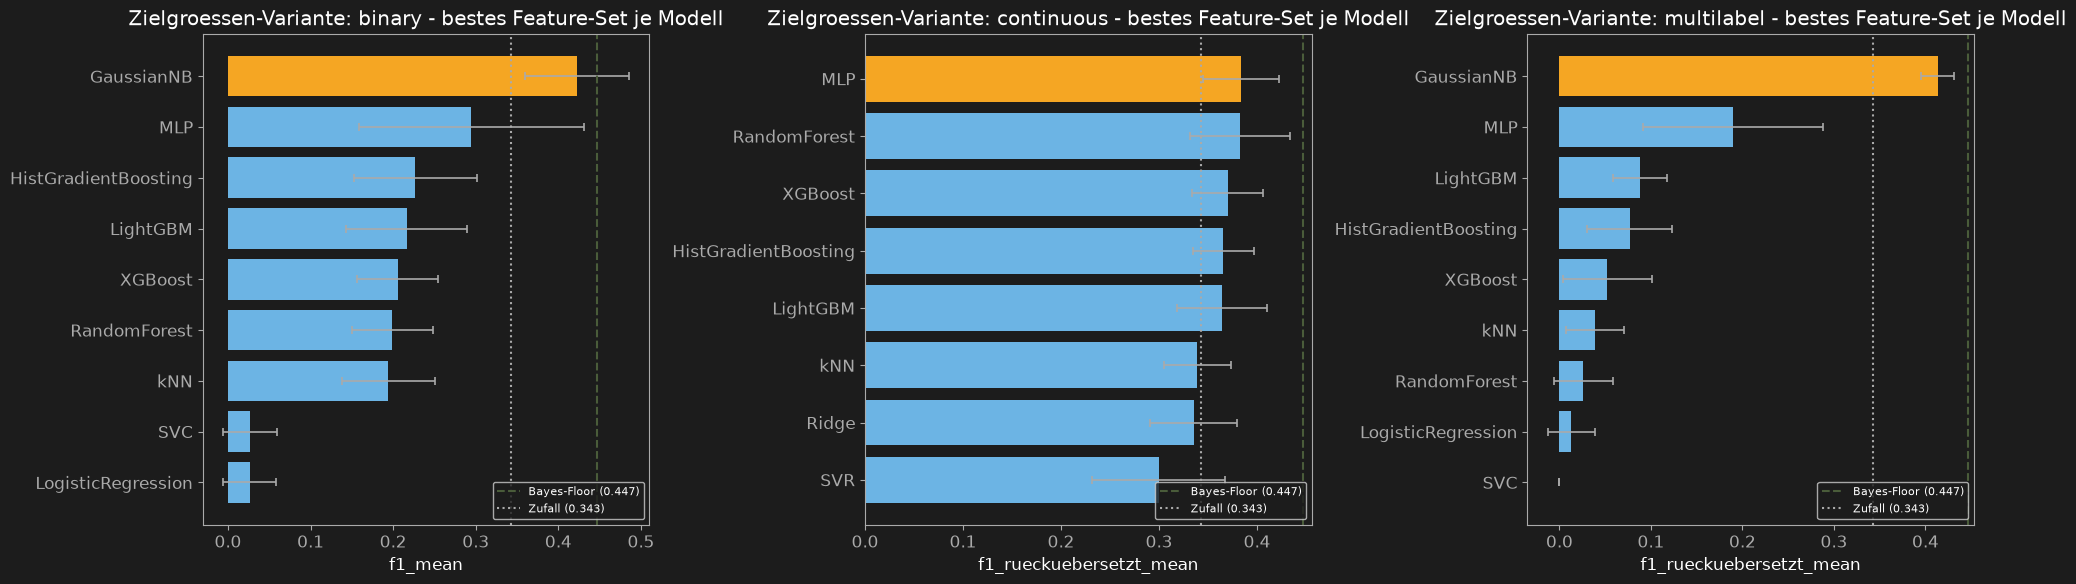

In [21]:
# =============================================================================
# Zelle 13 – Grafik 1: F1-Vergleich aller Modelle je Zielgroessen-Variante
# =============================================================================
BAYES_FLOOR = 0.447
ZUFALLS_BASELINE = 0.343

primary_metric = {"binary": "f1_mean", "continuous": "f1_rueckuebersetzt_mean", "multilabel": "f1_rueckuebersetzt_mean"}
primary_std = {"binary": "f1_std", "continuous": "f1_rueckuebersetzt_std", "multilabel": "f1_rueckuebersetzt_std"}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (tv, metric_col) in zip(axes, primary_metric.items()):
    std_col = primary_std[tv]
    sub = ergebnisse_df[ergebnisse_df["zielgroesse"] == tv]
    bestes_je_modell = sub.loc[sub.groupby("modell")[metric_col].idxmax()].sort_values(metric_col, ascending=True)

    farben = [COLOR_GOLD if m == bestes_je_modell[metric_col].idxmax() else COLOR_BLUE for m in bestes_je_modell.index]
    # KORREKTUR: error_kw setzt Fehlerbalken-Farbe explizit (sonst matplotlib-
    # Standard Schwarz, schlecht lesbar auf dunklem Hintergrund - gleiches
    # Problem wie bei Boxplots, siehe BOXPLOT_STYLE in viz_config_v2.py)
    ax.barh(bestes_je_modell["modell"], bestes_je_modell[metric_col],
            xerr=bestes_je_modell[std_col], color=farben,
            error_kw=dict(ecolor=COLOR_TEXT_MUTED, capsize=3, capthick=1.2, elinewidth=1.2))
    ax.axvline(BAYES_FLOOR, color=COLOR_GREEN, linestyle="--", linewidth=1.5, label=f"Bayes-Floor ({BAYES_FLOOR})")
    ax.axvline(ZUFALLS_BASELINE, color=COLOR_TEXT_MUTED, linestyle=":", linewidth=1.5, label=f"Zufall ({ZUFALLS_BASELINE})")
    ax.set_title(f"Zielgroessen-Variante: {tv} - bestes Feature-Set je Modell")
    ax.set_xlabel(metric_col)
    ax.legend(fontsize=8, loc="lower right")

plt.tight_layout()
save_figure(fig, "../reports/figures/05_ablation_f1_vergleich_modelle.png")
plt.show()

ergebnisse_df[ergebnisse_df["zielgroesse"].isin(primary_metric.keys())][
    ["zielgroesse","feature_set","modell"] + list(primary_std.values()) + list(primary_metric.values())
].to_csv("../reports/tables/05_ablation_f1_vergleich_modelle.csv", index=False)

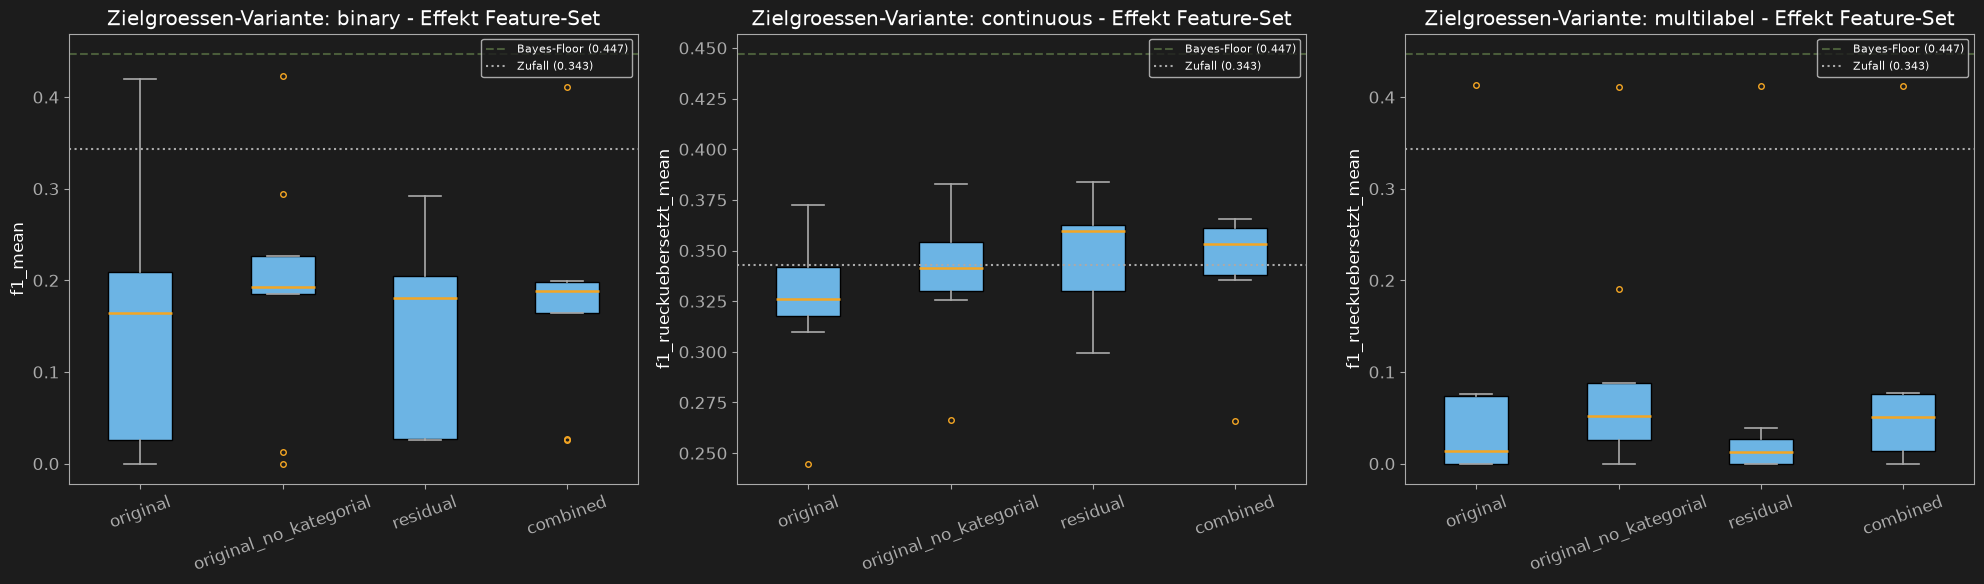

=== Median-F1 je Feature-Set und Zielgroessen-Variante ===

binary:
feature_set
original_no_kategorial    0.193
combined                  0.188
residual                  0.181
original                  0.164
Name: f1_mean, dtype: float64

continuous:
feature_set
residual                  0.360
combined                  0.353
original_no_kategorial    0.342
original                  0.326
Name: f1_rueckuebersetzt_mean, dtype: float64

multilabel:
feature_set
original_no_kategorial    0.052
combined                  0.051
original                  0.013
residual                  0.013
Name: f1_rueckuebersetzt_mean, dtype: float64


In [22]:
# =============================================================================
# Zelle 14 – Grafik 2: Effekt Feature-Set (Boxplot je Feature-Set, gepoolt ueber Modelle)
# =============================================================================
# Zeigt, ob ein Feature-Set systematisch besser/schlechter abschneidet als
# andere, unabhaengig vom verwendeten Modelltyp.
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (tv, metric_col) in zip(axes, primary_metric.items()):
    sub = ergebnisse_df[ergebnisse_df["zielgroesse"] == tv]
    daten_je_featureset = [sub[sub["feature_set"] == fs][metric_col].values for fs in FEATURE_SETS]

    bp = ax.boxplot(daten_je_featureset, tick_labels=list(FEATURE_SETS.keys()), patch_artist=True, **BOXPLOT_STYLE)
    for box in bp["boxes"]:
        box.set_facecolor(COLOR_BLUE)

    ax.axhline(BAYES_FLOOR, color=COLOR_GREEN, linestyle="--", linewidth=1.5, label=f"Bayes-Floor ({BAYES_FLOOR})")
    ax.axhline(ZUFALLS_BASELINE, color=COLOR_TEXT_MUTED, linestyle=":", linewidth=1.5, label=f"Zufall ({ZUFALLS_BASELINE})")
    ax.set_title(f"Zielgroessen-Variante: {tv} - Effekt Feature-Set")
    ax.set_ylabel(metric_col)
    ax.tick_params(axis="x", rotation=20)
    ax.legend(fontsize=8, loc="upper right")

plt.tight_layout()
save_figure(fig, "../reports/figures/05_ablation_effekt_feature_set.png")
plt.show()

for tv, metric_col in primary_metric.items():
    sub = ergebnisse_df[ergebnisse_df["zielgroesse"] == tv]
    sub.groupby("feature_set")[metric_col].describe().to_csv(f"../reports/tables/05_ablation_effekt_feature_set_{tv}.csv")

# --- Zusaetzlich: Median je Feature-Set als Tabelle ---
print("=== Median-F1 je Feature-Set und Zielgroessen-Variante ===")
for tv, metric_col in primary_metric.items():
    sub = ergebnisse_df[ergebnisse_df["zielgroesse"] == tv]
    print(f"\n{tv}:")
    print(sub.groupby("feature_set")[metric_col].median().sort_values(ascending=False).round(3))

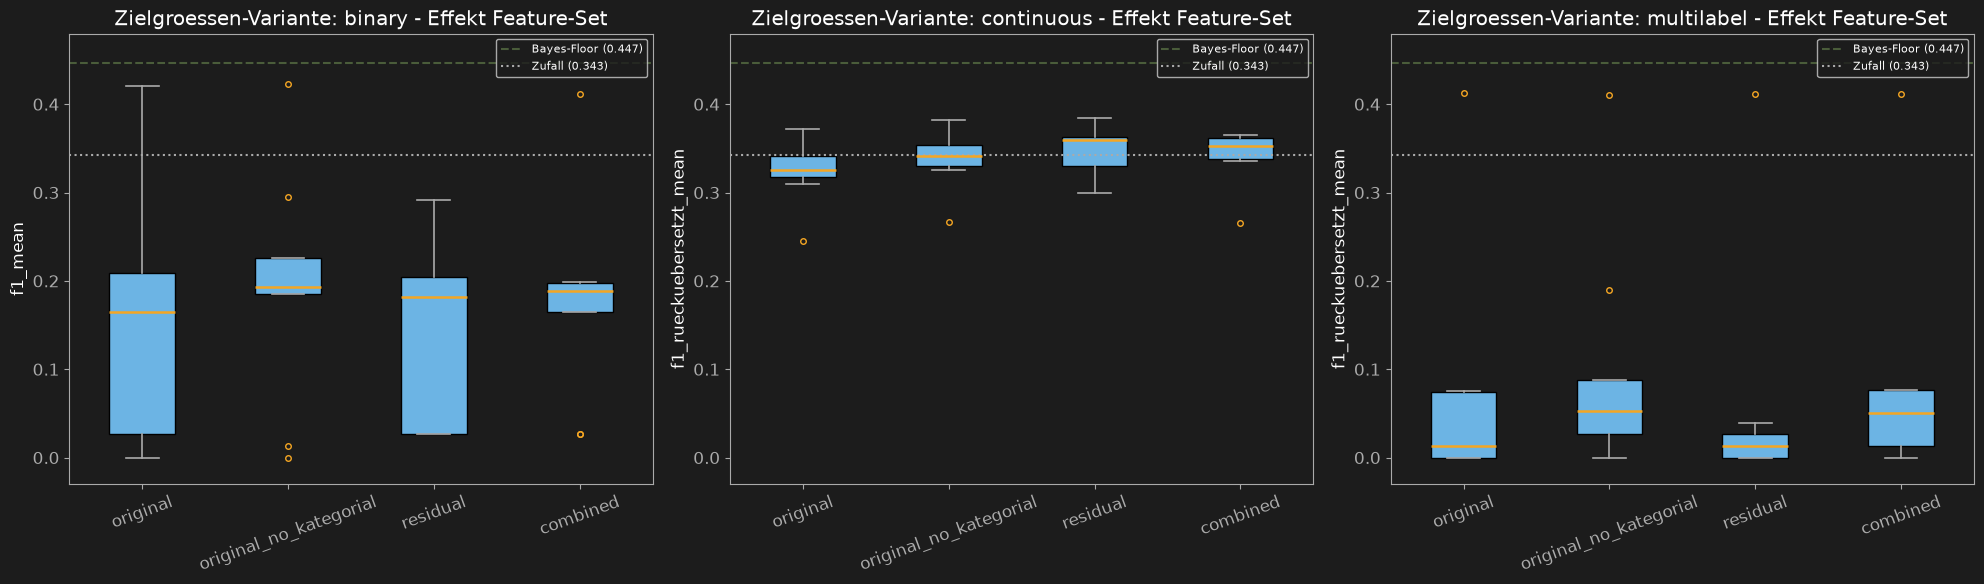

In [17]:
# =============================================================================
# Zelle 14b – Grafik 2b: wie Grafik 2, aber mit einheitlicher y-Achsen-Skala
# =============================================================================
# Ermoeglicht fairen visuellen Vergleich zwischen den drei Zielgroessen-
# Varianten - alle nutzen dieselbe F1-basierte Metrik-Skala.
# =============================================================================

Y_MIN, Y_MAX = -0.03, 0.48

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (tv, metric_col) in zip(axes, primary_metric.items()):
    sub = ergebnisse_df[ergebnisse_df["zielgroesse"] == tv]
    daten_je_featureset = [sub[sub["feature_set"] == fs][metric_col].values for fs in FEATURE_SETS]

    bp = ax.boxplot(daten_je_featureset, tick_labels=list(FEATURE_SETS.keys()), patch_artist=True, **BOXPLOT_STYLE)
    for box in bp["boxes"]:
        box.set_facecolor(COLOR_BLUE)

    ax.axhline(BAYES_FLOOR, color=COLOR_GREEN, linestyle="--", linewidth=1.5, label=f"Bayes-Floor ({BAYES_FLOOR})")
    ax.axhline(ZUFALLS_BASELINE, color=COLOR_TEXT_MUTED, linestyle=":", linewidth=1.5, label=f"Zufall ({ZUFALLS_BASELINE})")
    ax.set_title(f"Zielgroessen-Variante: {tv} - Effekt Feature-Set")
    ax.set_ylabel(metric_col)
    ax.set_ylim(Y_MIN, Y_MAX)
    ax.tick_params(axis="x", rotation=20)
    ax.legend(fontsize=8, loc="upper right")

plt.tight_layout()
save_figure(fig, "../reports/figures/05_ablation_effekt_feature_set_einheitliche_skala.png")
plt.show()

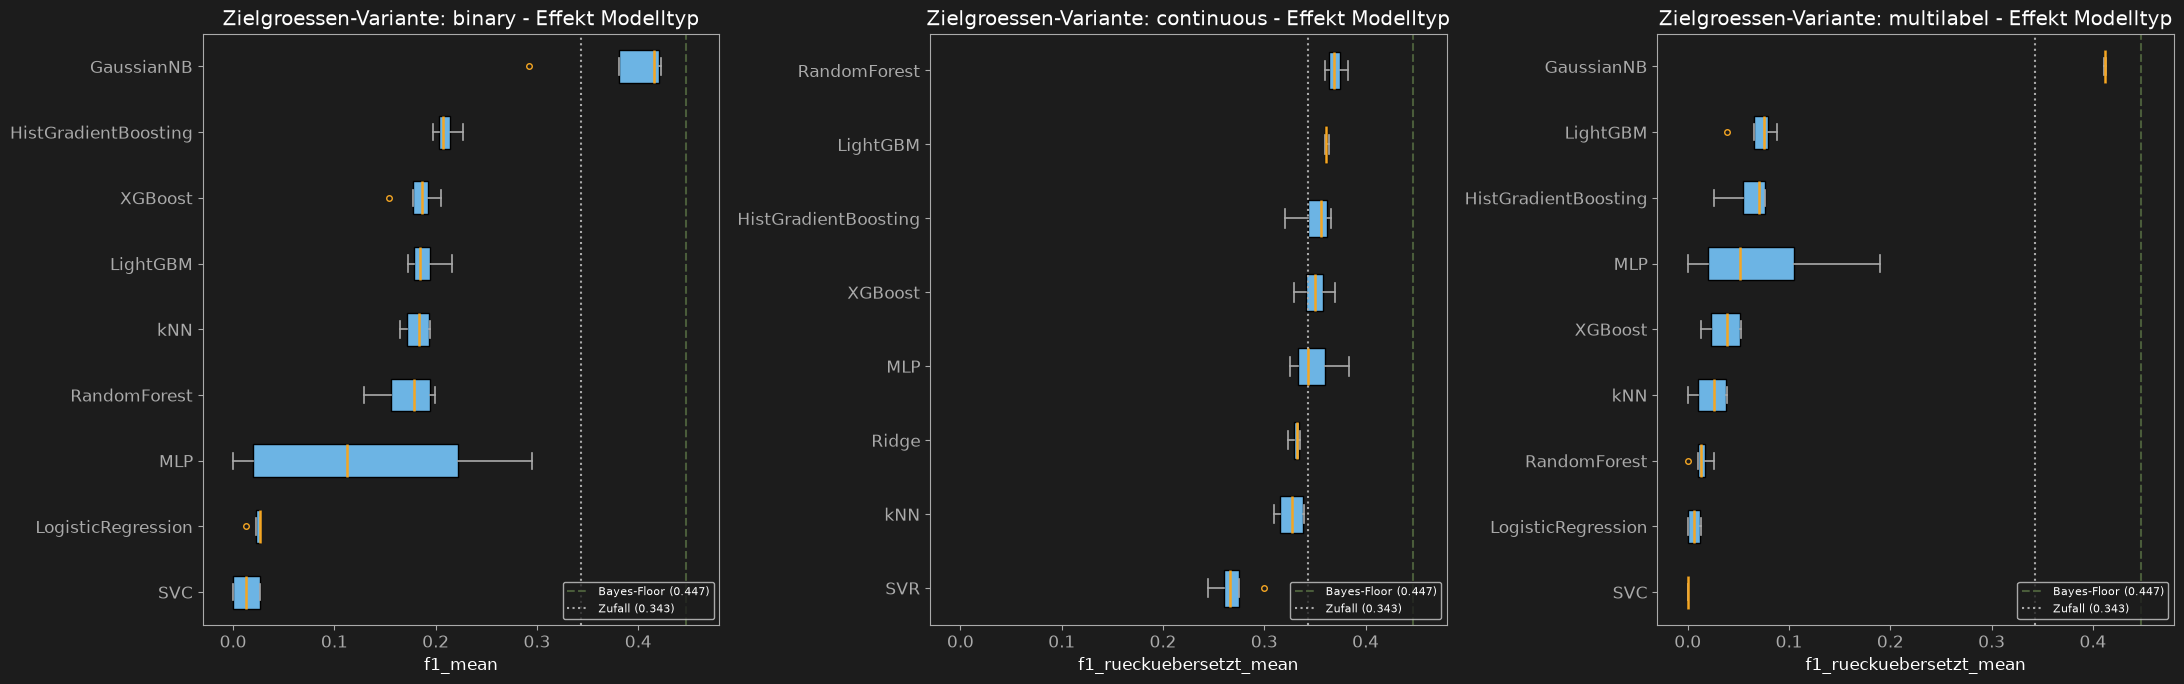

=== Spannweite (max-min) je Modell und Zielgroesse - Mass fuer Feature-Set-Empfindlichkeit ===

binary:
modell
MLP                     0.295
GaussianNB              0.131
RandomForest            0.070
XGBoost                 0.052
LightGBM                0.044
kNN                     0.030
HistGradientBoosting    0.029
SVC                     0.027
LogisticRegression      0.013
Name: f1_mean, dtype: float64

continuous:
modell
MLP                     0.058
SVR                     0.055
HistGradientBoosting    0.045
XGBoost                 0.041
kNN                     0.029
RandomForest            0.023
Ridge                   0.012
LightGBM                0.005
Name: f1_rueckuebersetzt_mean, dtype: float64

multilabel:
modell
MLP                     0.190
HistGradientBoosting    0.050
LightGBM                0.049
XGBoost                 0.040
kNN                     0.039
RandomForest            0.026
LogisticRegression      0.013
GaussianNB              0.002
SVC                    

In [23]:
# =============================================================================
# Zelle 15 – Grafik 3: Effekt Modelltyp (Boxplot je Modell, gepoolt ueber Feature-Sets)
# =============================================================================
# Zeigt Modell-Konsistenz: schmale Box = Modell robust gegenueber Feature-Set-
# Wahl, breite Box = Feature-Set-Wahl beeinflusst dieses Modell stark.
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

for ax, (tv, metric_col) in zip(axes, primary_metric.items()):
    sub = ergebnisse_df[ergebnisse_df["zielgroesse"] == tv]
    modelle_sortiert = sub.groupby("modell")[metric_col].median().sort_values(ascending=True).index.tolist()
    daten_je_modell = [sub[sub["modell"] == m][metric_col].values for m in modelle_sortiert]

    bp = ax.boxplot(daten_je_modell, tick_labels=modelle_sortiert, patch_artist=True, vert=False, **BOXPLOT_STYLE)
    for box in bp["boxes"]:
        box.set_facecolor(COLOR_BLUE)

    ax.axvline(BAYES_FLOOR, color=COLOR_GREEN, linestyle="--", linewidth=1.5, label=f"Bayes-Floor ({BAYES_FLOOR})")
    ax.axvline(ZUFALLS_BASELINE, color=COLOR_TEXT_MUTED, linestyle=":", linewidth=1.5, label=f"Zufall ({ZUFALLS_BASELINE})")
    ax.set_title(f"Zielgroessen-Variante: {tv} - Effekt Modelltyp")
    ax.set_xlabel(metric_col)
    ax.set_xlim(-0.03, 0.48)
    ax.legend(fontsize=8, loc="lower right")

plt.tight_layout()
save_figure(fig, "../reports/figures/05_ablation_effekt_modelltyp.png")
plt.show()

for tv, metric_col in primary_metric.items():
    sub = ergebnisse_df[ergebnisse_df["zielgroesse"] == tv]
    sub.groupby("modell")[metric_col].describe().to_csv(f"../reports/tables/05_ablation_effekt_modelltyp_{tv}.csv")

print("=== Spannweite (max-min) je Modell und Zielgroesse - Mass fuer Feature-Set-Empfindlichkeit ===")
for tv, metric_col in primary_metric.items():
    sub = ergebnisse_df[ergebnisse_df["zielgroesse"] == tv]
    spannweite = sub.groupby("modell")[metric_col].agg(lambda x: x.max() - x.min()).sort_values(ascending=False)
    print(f"\n{tv}:")
    print(spannweite.round(3))

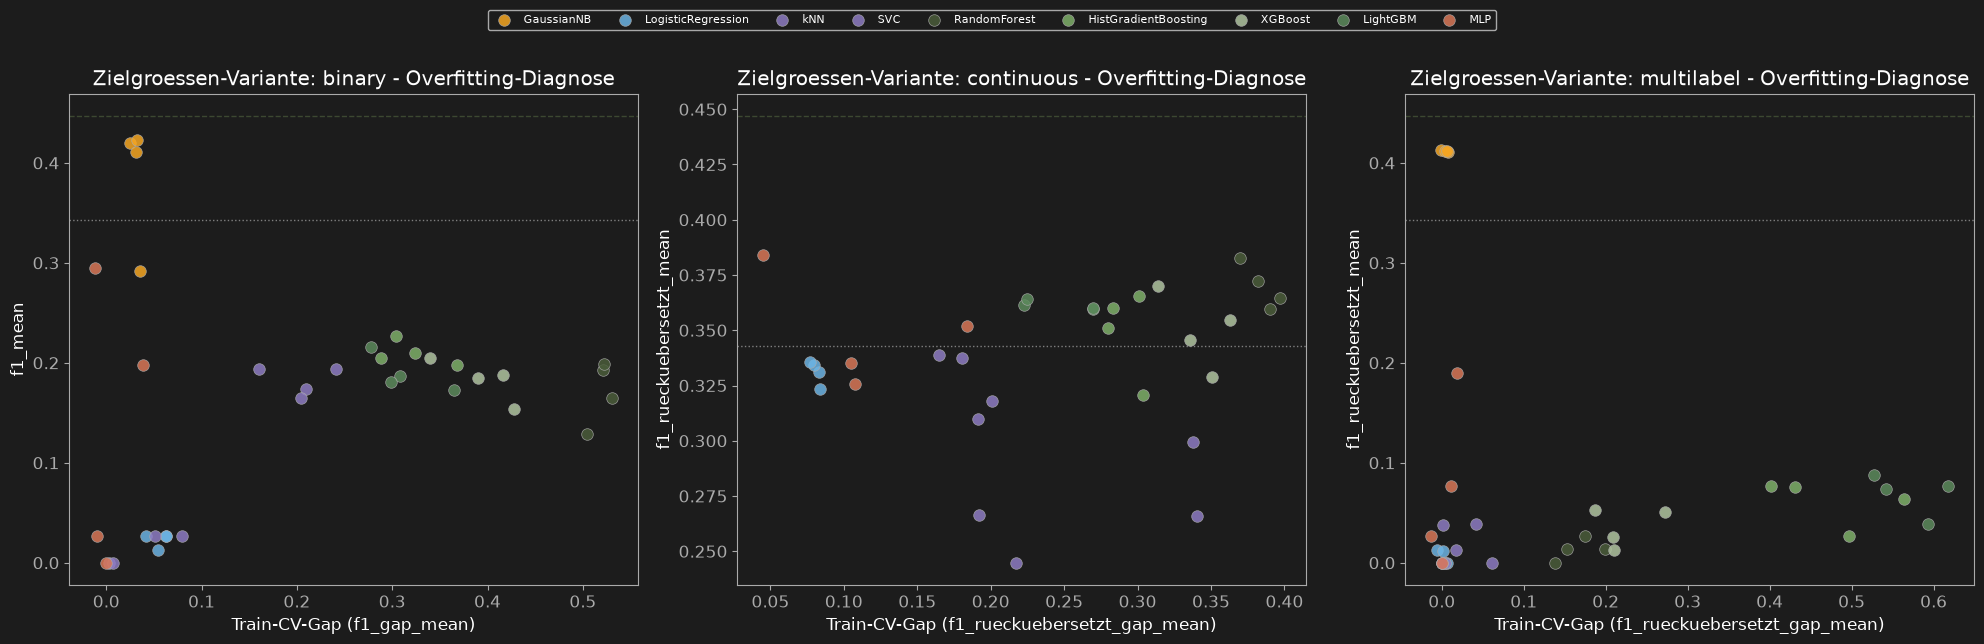

Gespeichert: reports/tables/05_ablation_overfitting_diagnose.csv


In [20]:
# =============================================================================
# Zelle 16 – Grafik 4: Train-CV-Gap vs. Validierungs-F1 (Overfitting-Diagnose)
# =============================================================================
# FARBSCHEMA-AUSNAHME: Store44 sieht nur 3 bedeutungstragende Akzentfarben vor
# (Gold/Blau/Gruen) - bei 9 gleichrangigen, individuell zu unterscheidenden
# Modelltypen fuehrt das zu Mehrfachbelegung und Verlust der Unterscheidbarkeit.
# Bewusste Ausnahme: erweiterte, dezente Palette (matplotlib tab10-Variante)
# nur fuer diese Art Vielkategorien-Vergleich, dokumentiert als Abweichung.
# =============================================================================

MODELL_PALETTE = {
    "GaussianNB": "#F5A623", "LogisticRegression": "#6CB4E4", "Ridge": "#6CB4E4",
    "kNN": "#8E7CC3", "SVC": "#8E7CC3", "SVR": "#8E7CC3",
    "RandomForest": "#4A5C3A", "HistGradientBoosting": "#7FB069",
    "XGBoost": "#B0C4A0", "LightGBM": "#5C8A5C", "MLP": "#D97757",
}

gap_col_map = {"binary": "f1_gap_mean", "continuous": "f1_rueckuebersetzt_gap_mean", "multilabel": "f1_rueckuebersetzt_gap_mean"}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
alle_scatter_daten = []

for ax, (tv, metric_col) in zip(axes, primary_metric.items()):
    gap_col = gap_col_map[tv]
    sub = ergebnisse_df[ergebnisse_df["zielgroesse"] == tv]

    for modell, farbe in MODELL_PALETTE.items():
        teil = sub[sub["modell"] == modell]
        if len(teil) == 0:
            continue
        ax.scatter(teil[gap_col], teil[metric_col], label=modell, color=farbe,
                   alpha=0.85, s=70, edgecolors=COLOR_TEXT_MUTED, linewidths=0.5)
        for _, row in teil.iterrows():
            alle_scatter_daten.append({
                "zielgroesse": tv, "modell": modell, "feature_set": row["feature_set"],
                "gap": row[gap_col], "validierungs_f1": row[metric_col]
            })

    ax.axhline(BAYES_FLOOR, color=COLOR_GREEN, linestyle="--", linewidth=1, alpha=0.7)
    ax.axhline(ZUFALLS_BASELINE, color=COLOR_TEXT_MUTED, linestyle=":", linewidth=1, alpha=0.7)
    ax.set_title(f"Zielgroessen-Variante: {tv} - Overfitting-Diagnose")
    ax.set_xlabel(f"Train-CV-Gap ({gap_col})")
    ax.set_ylabel(metric_col)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.08), ncol=9, fontsize=8)

plt.tight_layout()
save_figure(fig, "../reports/figures/05_ablation_overfitting_diagnose.png")
plt.show()

pd.DataFrame(alle_scatter_daten).to_csv("../reports/tables/05_ablation_overfitting_diagnose.csv", index=False)
print("Gespeichert: reports/tables/05_ablation_overfitting_diagnose.csv")

In [24]:
# =============================================================================
# Zelle 17 – Sane-Default-Kalibrierung Iteration 2: Klassenungleichgewicht
# =============================================================================
# Anlass: Grafik 1-4 zeigten mehrere Modelle (v.a. SVC, MLP) mit F1=0.000
# bei binaerer/multilabel Zielgroesse - sagen durchgaengig nur die
# Mehrheitsklasse (IO, 74%) vorher. class_weight="balanced" (bzw.
# scale_pos_weight bei XGBoost) gewichtet die Minderheitsklasse (NIO)
# staerker im Trainingsprozess - eine begruendete Sane-Default-Korrektur
# (kein Tuning, da nicht gesucht sondern aus einem beobachteten
# Fehlermuster abgeleitet). MLP bewusst ausgenommen: sklearn's MLPClassifier
# unterstuetzt kein class_weight (kein Resampling-Ansatz eingefuehrt, da
# das ueber eine einzelne Sane-Default-Korrektur hinausginge).
# =============================================================================

nio_anteil_train = (df.loc[train_idx, "io_nio"] == "NIO").mean()
scale_pos_weight_wert = (1 - nio_anteil_train) / nio_anteil_train  # Verhaeltnis IO:NIO
print(f"NIO-Anteil Training: {nio_anteil_train:.3f}, scale_pos_weight: {scale_pos_weight_wert:.2f}")

MODELLE_BINAER_V2 = {
    "LogisticRegression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED),
    "kNN": KNeighborsClassifier(n_neighbors=5),  # kein class_weight-Parameter
    "SVC": SVC(C=1.0, kernel="rbf", class_weight="balanced", random_state=SEED),
    "RandomForest": RandomForestClassifier(n_estimators=200, max_depth=8, min_samples_leaf=3, class_weight="balanced", random_state=SEED),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        max_iter=50, max_depth=3, max_leaf_nodes=15, min_samples_leaf=20, l2_regularization=1.0,
        class_weight="balanced", random_state=SEED),
    "XGBoost": XGBClassifier(
        n_estimators=50, max_depth=3, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8,
        reg_lambda=2.0, scale_pos_weight=scale_pos_weight_wert, random_state=SEED, eval_metric="logloss"),
    "LightGBM": LGBMClassifier(
        n_estimators=50, num_leaves=7, max_depth=3, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8,
        min_child_samples=30, class_weight="balanced", random_state=SEED, verbose=-1),
    "GaussianNB": GaussianNB(),  # kein class_weight-Parameter, bereits stark
    "MLP": MLPClassifier(hidden_layer_sizes=(50,), max_iter=1000, early_stopping=True, random_state=SEED),  # unveraendert, kein class_weight verfuegbar
}

MODELLE_MULTILABEL_V2 = {
    "LogisticRegression": MultiOutputClassifier(LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED)),
    "kNN": MultiOutputClassifier(KNeighborsClassifier(n_neighbors=5)),
    "SVC": MultiOutputClassifier(SVC(C=1.0, kernel="rbf", class_weight="balanced", random_state=SEED)),
    "RandomForest": MultiOutputClassifier(RandomForestClassifier(n_estimators=200, max_depth=8, min_samples_leaf=3, class_weight="balanced", random_state=SEED)),
    "HistGradientBoosting": MultiOutputClassifier(HistGradientBoostingClassifier(
        max_iter=50, max_depth=3, max_leaf_nodes=15, min_samples_leaf=20, l2_regularization=1.0,
        class_weight="balanced", random_state=SEED)),
    "XGBoost": MultiOutputClassifier(XGBClassifier(
        n_estimators=50, max_depth=3, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8,
        reg_lambda=2.0, random_state=SEED, eval_metric="logloss")),  # scale_pos_weight je Label unterschiedlich, hier ausgelassen
    "LightGBM": MultiOutputClassifier(LGBMClassifier(
        n_estimators=50, num_leaves=7, max_depth=3, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8,
        min_child_samples=30, class_weight="balanced", random_state=SEED, verbose=-1)),
    "GaussianNB": MultiOutputClassifier(GaussianNB()),
    "MLP": MultiOutputClassifier(MLPClassifier(hidden_layer_sizes=(50,), max_iter=1000, early_stopping=True, random_state=SEED)),
}

print("Modell-Registry V2 (mit class_weight) definiert.")

NIO-Anteil Training: 0.261, scale_pos_weight: 2.84
Modell-Registry V2 (mit class_weight) definiert.


In [25]:
# =============================================================================
# Zelle 18 – Ablationsschleife Iteration 2: nur binaer + multilabel mit V2-Registry
# =============================================================================
# continuous unveraendert (keine Klassifikations-Klassengewichtung anwendbar) -
# nur binary/multilabel werden neu berechnet und ERSETZEN die alten Zeilen.
# =============================================================================

MODELL_REGISTRY_V2 = {"binary": MODELLE_BINAER_V2, "multilabel": MODELLE_MULTILABEL_V2}

ergebnisse_v2 = []
kombi_counter = 0
gesamt_kombis = sum(len(FEATURE_SETS) * len(MODELL_REGISTRY_V2[tv]) for tv in MODELL_REGISTRY_V2)
start_gesamt = time.time()

for target_variant in MODELL_REGISTRY_V2:
    y_full, valid_mask = get_target(df, target_variant, respect_mask=True)

    for feature_set_name in FEATURE_SETS:
        for modell_name, modell in MODELL_REGISTRY_V2[target_variant].items():
            kombi_counter += 1
            eintrag = {"zielgroesse": target_variant, "feature_set": feature_set_name, "modell": modell_name, "status": "ok"}
            fold_metriken_val, fold_metriken_train, fold_zeiten = [], [], []

            try:
                for tr_idx, val_idx in fold_splits_idx:
                    tr_idx_eff, val_idx_eff = tr_idx, val_idx

                    prep = baue_preprocessing_pipeline(feature_set_name)
                    X_tr = prep.fit_transform(df.loc[tr_idx_eff])
                    X_val = prep.transform(df.loc[val_idx_eff])
                    y_tr = y_full.loc[tr_idx_eff]
                    y_val = y_full.loc[val_idx_eff]

                    modell_fold = clone(modell)
                    label_kodiert = (target_variant == "binary" and modell_name == "XGBoost")
                    y_tr_fit = (y_tr == "NIO").astype(int) if label_kodiert else y_tr

                    t0 = time.time()
                    modell_fold.fit(X_tr, y_tr_fit)
                    fold_zeiten.append(time.time() - t0)

                    def _predict_zurueckuebersetzt(X):
                        pred_roh = modell_fold.predict(X)
                        if label_kodiert:
                            return np.where(pred_roh == 1, "NIO", "IO")
                        return pred_roh

                    y_pred_val = _predict_zurueckuebersetzt(X_val)
                    y_pred_train = _predict_zurueckuebersetzt(X_tr)

                    if target_variant == "binary":
                        y_proba_val, y_proba_train = None, None
                        if hasattr(modell_fold, "predict_proba"):
                            klassen = list(modell_fold.classes_)
                            idx_nio = klassen.index(1) if label_kodiert else klassen.index("NIO")
                            y_proba_val = modell_fold.predict_proba(X_val)[:, idx_nio]
                            y_proba_train = modell_fold.predict_proba(X_tr)[:, idx_nio]
                        m_val = metriken_binaer(y_val, y_pred_val, y_proba_val)
                        m_train = metriken_binaer(y_tr, y_pred_train, y_proba_train)
                    else:
                        m_val = metriken_multilabel(y_val.values, y_pred_val)
                        m_train = metriken_multilabel(y_tr.values, y_pred_train)

                    fold_metriken_val.append(m_val)
                    fold_metriken_train.append(m_train)

                for k in fold_metriken_val[0].keys():
                    werte_val = [fm[k] for fm in fold_metriken_val]
                    werte_train = [fm[k] for fm in fold_metriken_train]
                    eintrag[f"{k}_mean"] = np.nanmean(werte_val)
                    eintrag[f"{k}_std"] = np.nanstd(werte_val)
                    eintrag[f"train_{k}_mean"] = np.nanmean(werte_train)
                    gaps = [t - v for t, v in zip(werte_train, werte_val)]
                    eintrag[f"{k}_gap_mean"] = np.nanmean(gaps)

                eintrag["fit_time_sekunden_mean"] = np.mean(fold_zeiten)
                eintrag["n_folds_erfolgreich"] = len(fold_metriken_val)

            except Exception as e:
                eintrag["status"] = "fehlgeschlagen"
                eintrag["fehler"] = f"{type(e).__name__}: {str(e)[:200]}"

            ergebnisse_v2.append(eintrag)
            print(f"[{kombi_counter}/{gesamt_kombis}] {target_variant:12s} {feature_set_name:25s} {modell_name:20s} -> {eintrag['status']}")

print(f"\nGesamtzeit: {time.time()-start_gesamt:.1f}s")
ergebnisse_v2_df = pd.DataFrame(ergebnisse_v2)
print(f"Erfolgreich: {(ergebnisse_v2_df['status']=='ok').sum()} / {len(ergebnisse_v2_df)}")

[1/72] binary       original                  LogisticRegression   -> ok
[2/72] binary       original                  kNN                  -> ok
[3/72] binary       original                  SVC                  -> ok
[4/72] binary       original                  RandomForest         -> ok
[5/72] binary       original                  HistGradientBoosting -> ok
[6/72] binary       original                  XGBoost              -> ok
[7/72] binary       original                  LightGBM             -> ok
[8/72] binary       original                  GaussianNB           -> ok
[9/72] binary       original                  MLP                  -> ok
[10/72] binary       original_no_kategorial    LogisticRegression   -> ok
[11/72] binary       original_no_kategorial    kNN                  -> ok
[12/72] binary       original_no_kategorial    SVC                  -> ok
[13/72] binary       original_no_kategorial    RandomForest         -> ok
[14/72] binary       original_no_kategorial    

In [26]:
# =============================================================================
# Zelle 19 – Vorher-Nachher-Vergleich: Wirksamkeit von class_weight bestaetigen
# =============================================================================
alt_binaer = ergebnisse_df[ergebnisse_df["zielgroesse"]=="binary"][["feature_set","modell","f1_mean","f1_std"]].rename(columns={"f1_mean":"f1_mean_ALT","f1_std":"f1_std_ALT"})
neu_binaer = ergebnisse_v2_df[ergebnisse_v2_df["zielgroesse"]=="binary"][["feature_set","modell","f1_mean","f1_std"]].rename(columns={"f1_mean":"f1_mean_NEU","f1_std":"f1_std_NEU"})
vergleich_binaer = alt_binaer.merge(neu_binaer, on=["feature_set","modell"])
vergleich_binaer["differenz"] = vergleich_binaer["f1_mean_NEU"] - vergleich_binaer["f1_mean_ALT"]

print("=== Vorher-Nachher: binaer (sortiert nach groesster Verbesserung) ===")
print(vergleich_binaer.sort_values("differenz", ascending=False).to_string(index=False))

alt_multi = ergebnisse_df[ergebnisse_df["zielgroesse"]=="multilabel"][["feature_set","modell","f1_rueckuebersetzt_mean"]].rename(columns={"f1_rueckuebersetzt_mean":"f1_ALT"})
neu_multi = ergebnisse_v2_df[ergebnisse_v2_df["zielgroesse"]=="multilabel"][["feature_set","modell","f1_rueckuebersetzt_mean"]].rename(columns={"f1_rueckuebersetzt_mean":"f1_NEU"})
vergleich_multi = alt_multi.merge(neu_multi, on=["feature_set","modell"])
vergleich_multi["differenz"] = vergleich_multi["f1_NEU"] - vergleich_multi["f1_ALT"]

print("\n=== Vorher-Nachher: multilabel (sortiert nach groesster Verbesserung) ===")
print(vergleich_multi.sort_values("differenz", ascending=False).to_string(index=False))

vergleich_binaer.to_csv("../reports/tables/05_ablation_sane_default_v2_vergleich_binary.csv", index=False)
vergleich_multi.to_csv("../reports/tables/05_ablation_sane_default_v2_vergleich_multilabel.csv", index=False)

=== Vorher-Nachher: binaer (sortiert nach groesster Verbesserung) ===
           feature_set               modell  f1_mean_ALT  f1_std_ALT  f1_mean_NEU  f1_std_NEU    differenz
              original                  SVC     0.000000    0.000000     0.409674    0.063172 4.096736e-01
original_no_kategorial                  SVC     0.000000    0.000000     0.398410    0.052467 3.984097e-01
              combined                  SVC     0.026667    0.032660     0.395210    0.070758 3.685437e-01
              residual                  SVC     0.026237    0.032140     0.391858    0.057332 3.656211e-01
original_no_kategorial   LogisticRegression     0.012903    0.025806     0.374707    0.037212 3.618039e-01
              original   LogisticRegression     0.026237    0.032140     0.382247    0.041333 3.560103e-01
              combined   LogisticRegression     0.026237    0.032140     0.380377    0.028274 3.541400e-01
              residual   LogisticRegression     0.026237    0.032140     0

## Abschnitt: Finale Ergebnisse nach Sane-Default-Kalibrierung (Iteration 2)

Nach Analyse der ersten vollstaendigen Ablationsschleife (Grafiken 1-4)
wurde ein systematisches Problem bei mehreren Modellen identifiziert:
SVC, LogisticRegression und teilweise weitere zeigten bei binaerer/
Multi-Label-Zielgroesse ein Kollabieren auf die Mehrheitsklasse (F1=0),
bedingt durch das Klassenungleichgewicht (26% NIO) und Standard-
Hyperparameter ohne Klassengewichtung.

Korrekturmassnahme (Sane-Default-Kalibrierung, kein Tuning): class_weight=
"balanced" (bzw. scale_pos_weight bei XGBoost) fuer alle Modelle ergaenzt,
die diesen Parameter unterstuetzen. MLP und GaussianNB bewusst
ausgenommen (kein natives class_weight in sklearn verfuegbar; ein
Ausweichen auf Resampling-Verfahren wuerde die Grenze zu echtem Tuning
ueberschreiten).

Iteration 2 der Ablationsschleife (72 Kombinationen: binaer + multilabel,
4 Feature-Sets x 9 Modelle) durchgefuehrt und gegen Iteration 1
verglichen. Ergebnis (siehe Zelle 19): massive, statistisch klar sichtbare
Verbesserung bei SVC/LogisticRegression (binaer: +0.35 bis +0.41 F1,
multilabel: +0.40 bis +0.43 F1) sowie spuerbare Verbesserung bei allen
baumbasierten Modellen (+0.11 bis +0.34). GaussianNB unveraendert (0.000
Differenz, erwartungsgemaess, kein class_weight-Parameter).

**Wichtige Neueinordnung:** GaussianNB ist nach dieser Korrektur nicht
mehr der alleinige, klare Spitzenreiter - SVC und LogisticRegression
liegen nun in vergleichbarer Groessenordnung. Ein wesentlicher Teil des
vorherigen GaussianNB-Vorsprungs lag an einem behebbaren Konfigurations-
mangel der Konkurrenzmodelle, nicht ausschliesslich an einer besonderen
methodischen Eignung von Naive Bayes fuer dieses Problem.

Ab hier: alle folgenden Grafiken/Tabellen basieren auf der finalen,
konsolidierten Ergebnistabelle (binaer/multilabel = Iteration 2,
continuous = Iteration 1, da class_weight fuer Regression nicht
anwendbar ist).

In [27]:
# =============================================================================
# Zelle 21 – Finale konsolidierte Ergebnistabelle (alle 104 Kombinationen)
# =============================================================================
# Single Source of Truth fuer alle finalen Grafiken/Analysen und die
# spaetere Champion-Modell-Auswahl. Kombiniert:
# - binary/multilabel: V2 (nach Sane-Default-Kalibrierung, class_weight)
# - continuous: V1 (unveraendert, class_weight nicht anwendbar auf Regression)
# Zusatzspalte kalibrierungs_version dokumentiert Herkunft je Zeile.
# =============================================================================

binaer_final = ergebnisse_v2_df[ergebnisse_v2_df["zielgroesse"]=="binary"].copy()
multilabel_final = ergebnisse_v2_df[ergebnisse_v2_df["zielgroesse"]=="multilabel"].copy()
continuous_final = ergebnisse_df[ergebnisse_df["zielgroesse"]=="continuous"].copy()

binaer_final["kalibrierungs_version"] = "v2_class_weight_balanced"
multilabel_final["kalibrierungs_version"] = "v2_class_weight_balanced"
continuous_final["kalibrierungs_version"] = "v1_original_hyperparameter"

ergebnisse_final_df = pd.concat([binaer_final, multilabel_final, continuous_final], ignore_index=True)

print(f"Finale konsolidierte Tabelle: {ergebnisse_final_df.shape}")
print(f"Zeilen je Zielgroesse:\n{ergebnisse_final_df['zielgroesse'].value_counts()}")
print(f"Zeilen je Kalibrierungs-Version:\n{ergebnisse_final_df['kalibrierungs_version'].value_counts()}")

ergebnisse_final_df.to_csv("../reports/tables/05_ablation_results_final.csv", index=False)
print("\nGespeichert: reports/tables/05_ablation_results_final.csv")

Finale konsolidierte Tabelle: (104, 55)
Zeilen je Zielgroesse:
zielgroesse
binary        36
multilabel    36
continuous    32
Name: count, dtype: int64
Zeilen je Kalibrierungs-Version:
kalibrierungs_version
v2_class_weight_balanced      72
v1_original_hyperparameter    32
Name: count, dtype: int64

Gespeichert: reports/tables/05_ablation_results_final.csv


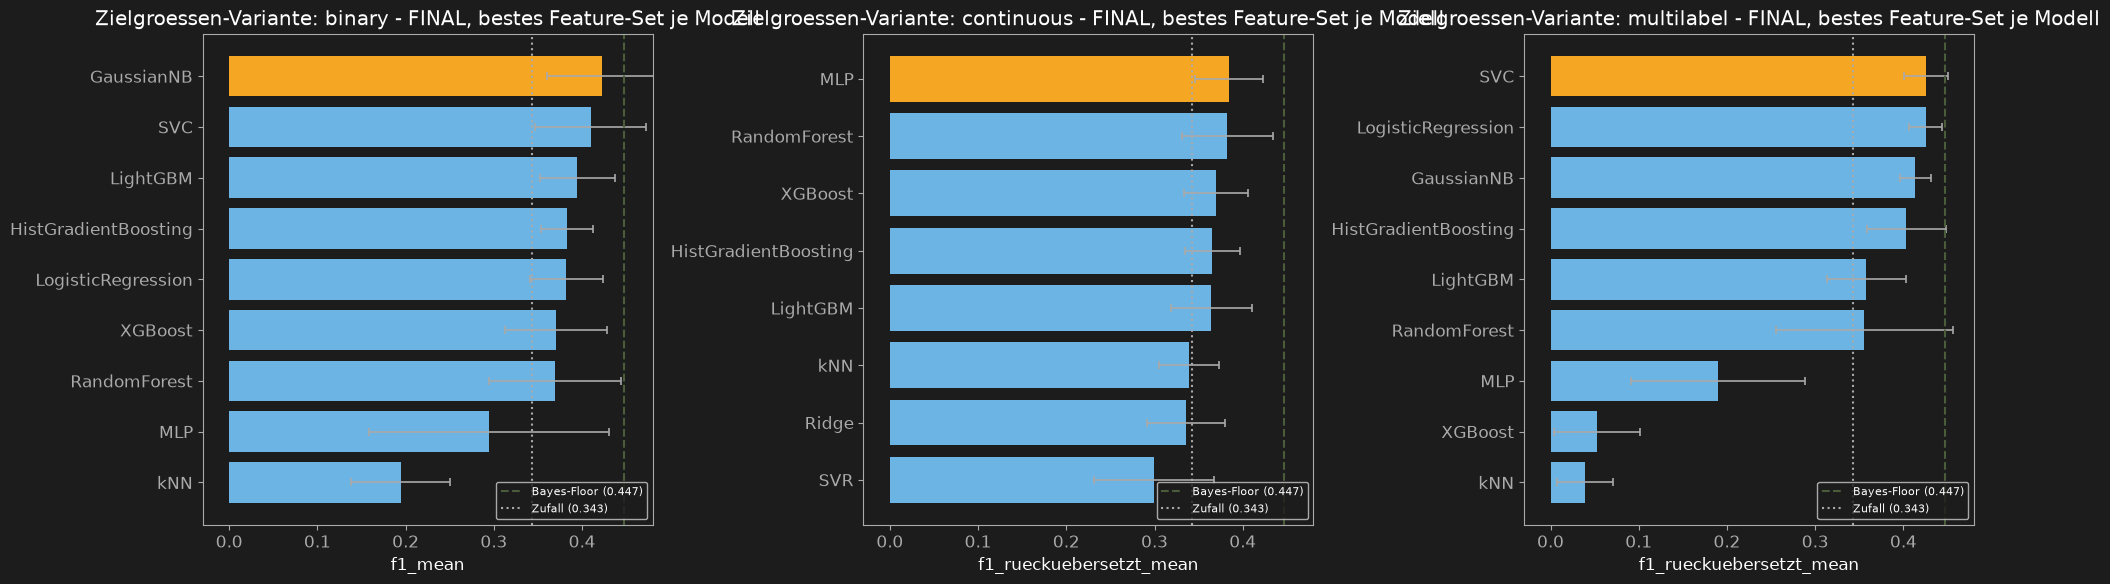

=== Top 3 je Zielgroessen-Variante (final) ===

binary:
           feature_set     modell  f1_mean
original_no_kategorial GaussianNB 0.422805
              original GaussianNB 0.420235
              combined GaussianNB 0.411099

continuous:
           feature_set       modell  f1_rueckuebersetzt_mean
              residual          MLP                 0.383997
original_no_kategorial RandomForest                 0.382672
              original RandomForest                 0.372295

multilabel:
           feature_set             modell  f1_rueckuebersetzt_mean
original_no_kategorial                SVC                 0.425343
              combined LogisticRegression                 0.425175
              residual LogisticRegression                 0.424817


In [28]:
# =============================================================================
# Zelle 22 – Grafik 1 (FINAL): F1-Vergleich nach Sane-Default-Kalibrierung
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (tv, metric_col) in zip(axes, primary_metric.items()):
    std_col = primary_std[tv]
    sub = ergebnisse_final_df[ergebnisse_final_df["zielgroesse"] == tv]
    bestes_je_modell = sub.loc[sub.groupby("modell")[metric_col].idxmax()].sort_values(metric_col, ascending=True)

    farben = [COLOR_GOLD if m == bestes_je_modell[metric_col].idxmax() else COLOR_BLUE for m in bestes_je_modell.index]
    ax.barh(bestes_je_modell["modell"], bestes_je_modell[metric_col],
            xerr=bestes_je_modell[std_col], color=farben,
            error_kw=dict(ecolor=COLOR_TEXT_MUTED, capsize=3, capthick=1.2, elinewidth=1.2))
    ax.axvline(BAYES_FLOOR, color=COLOR_GREEN, linestyle="--", linewidth=1.5, label=f"Bayes-Floor ({BAYES_FLOOR})")
    ax.axvline(ZUFALLS_BASELINE, color=COLOR_TEXT_MUTED, linestyle=":", linewidth=1.5, label=f"Zufall ({ZUFALLS_BASELINE})")
    ax.set_title(f"Zielgroessen-Variante: {tv} - FINAL, bestes Feature-Set je Modell")
    ax.set_xlabel(metric_col)
    ax.set_xlim(-0.03, 0.48)
    ax.legend(fontsize=8, loc="lower right")

plt.tight_layout()
save_figure(fig, "../reports/figures/05_ablation_f1_vergleich_modelle_final.png")
plt.show()

ergebnisse_final_df[ergebnisse_final_df["zielgroesse"].isin(primary_metric.keys())][
    ["zielgroesse","feature_set","modell","kalibrierungs_version"] + list(primary_std.values()) + list(primary_metric.values())
].to_csv("../reports/tables/05_ablation_f1_vergleich_modelle_final.csv", index=False)

print("=== Top 3 je Zielgroessen-Variante (final) ===")
for tv, metric_col in primary_metric.items():
    sub = ergebnisse_final_df[ergebnisse_final_df["zielgroesse"] == tv].sort_values(metric_col, ascending=False)
    print(f"\n{tv}:")
    print(sub[["feature_set","modell",metric_col]].head(3).to_string(index=False))

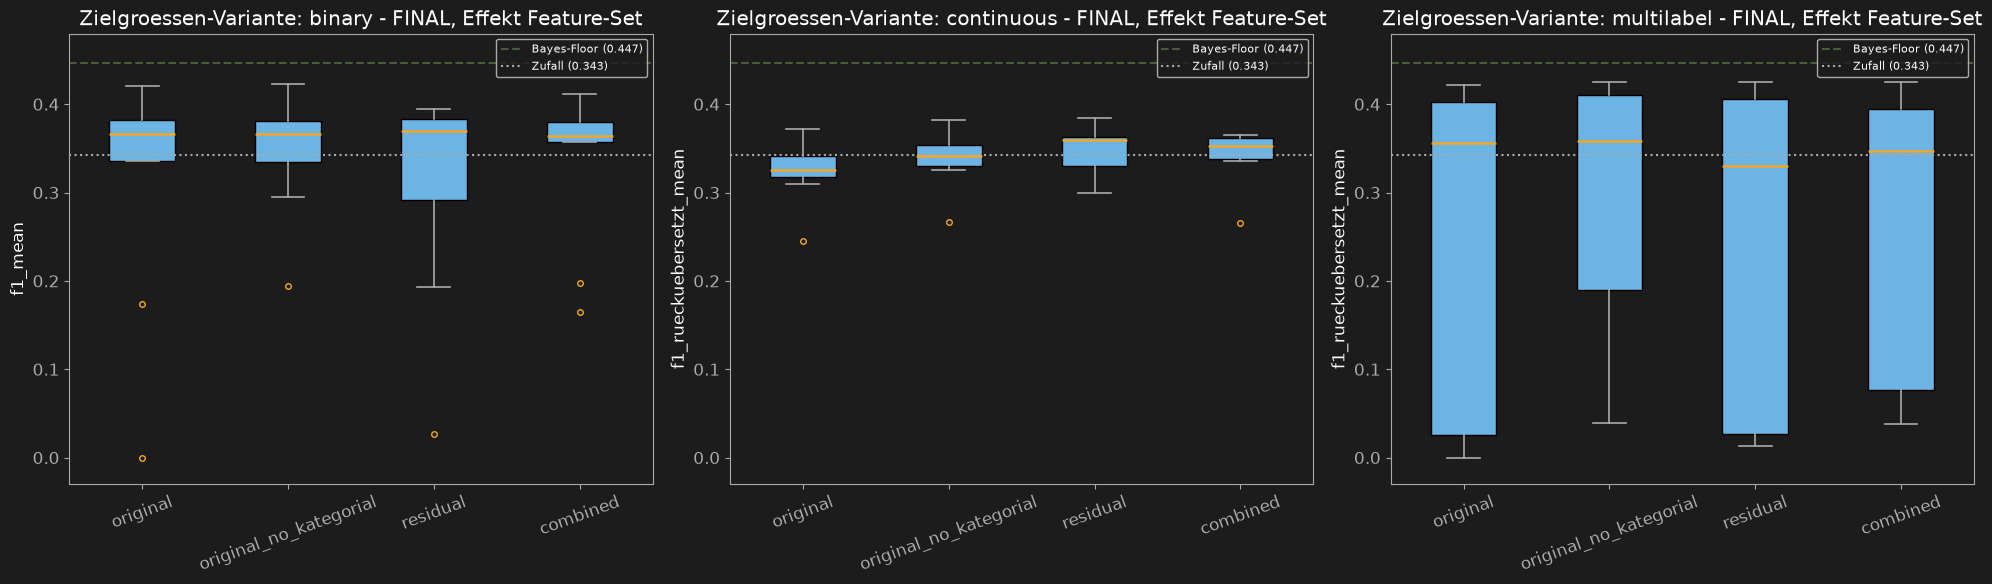

=== Median-F1 je Feature-Set (final) ===

binary:
feature_set
residual                  0.370
original                  0.367
original_no_kategorial    0.366
combined                  0.364
Name: f1_mean, dtype: float64

continuous:
feature_set
residual                  0.360
combined                  0.353
original_no_kategorial    0.342
original                  0.326
Name: f1_rueckuebersetzt_mean, dtype: float64

multilabel:
feature_set
original_no_kategorial    0.358
original                  0.356
combined                  0.347
residual                  0.330
Name: f1_rueckuebersetzt_mean, dtype: float64


In [29]:
# =============================================================================
# Zelle 23 – Grafik 2 (FINAL): Effekt Feature-Set nach Sane-Default-Kalibrierung
# =============================================================================
Y_MIN, Y_MAX = -0.03, 0.48

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (tv, metric_col) in zip(axes, primary_metric.items()):
    sub = ergebnisse_final_df[ergebnisse_final_df["zielgroesse"] == tv]
    daten_je_featureset = [sub[sub["feature_set"] == fs][metric_col].values for fs in FEATURE_SETS]

    bp = ax.boxplot(daten_je_featureset, tick_labels=list(FEATURE_SETS.keys()), patch_artist=True, **BOXPLOT_STYLE)
    for box in bp["boxes"]:
        box.set_facecolor(COLOR_BLUE)

    ax.axhline(BAYES_FLOOR, color=COLOR_GREEN, linestyle="--", linewidth=1.5, label=f"Bayes-Floor ({BAYES_FLOOR})")
    ax.axhline(ZUFALLS_BASELINE, color=COLOR_TEXT_MUTED, linestyle=":", linewidth=1.5, label=f"Zufall ({ZUFALLS_BASELINE})")
    ax.set_title(f"Zielgroessen-Variante: {tv} - FINAL, Effekt Feature-Set")
    ax.set_ylabel(metric_col)
    ax.set_ylim(Y_MIN, Y_MAX)
    ax.tick_params(axis="x", rotation=20)
    ax.legend(fontsize=8, loc="upper right")

plt.tight_layout()
save_figure(fig, "../reports/figures/05_ablation_effekt_feature_set_final.png")
plt.show()

print("=== Median-F1 je Feature-Set (final) ===")
for tv, metric_col in primary_metric.items():
    sub = ergebnisse_final_df[ergebnisse_final_df["zielgroesse"] == tv]
    sub.groupby("feature_set")[metric_col].describe().to_csv(f"../reports/tables/05_ablation_effekt_feature_set_{tv}_final.csv")
    print(f"\n{tv}:")
    print(sub.groupby("feature_set")[metric_col].median().sort_values(ascending=False).round(3))

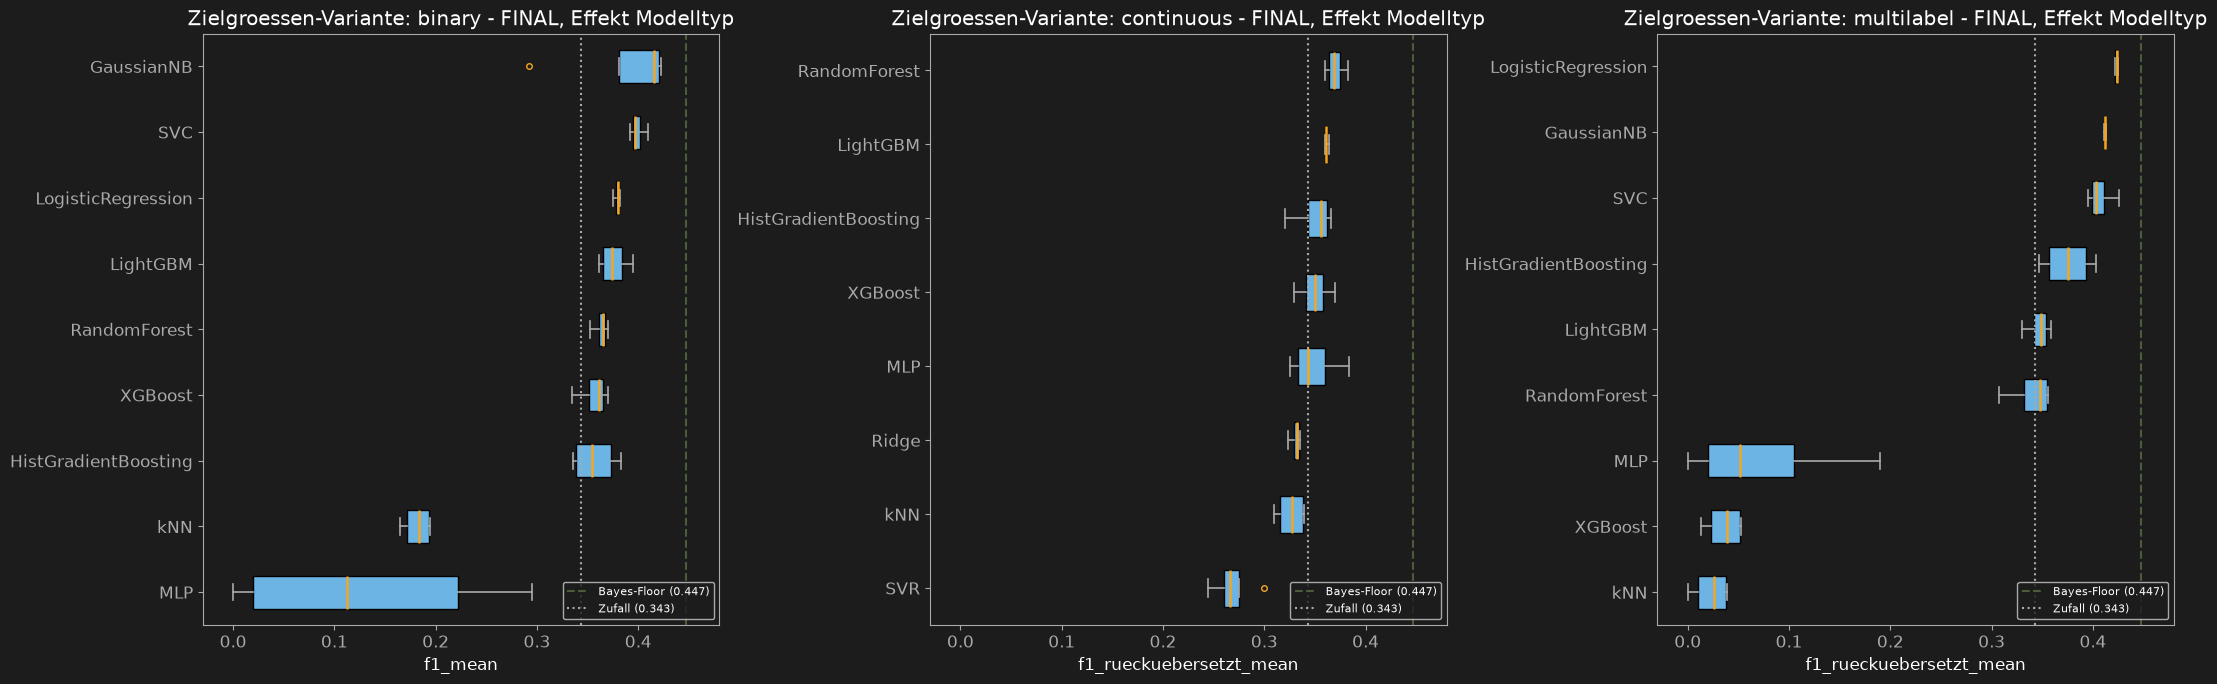

=== Spannweite (max-min) je Modell (final) ===

binary:
modell
MLP                     0.295
GaussianNB              0.131
HistGradientBoosting    0.047
XGBoost                 0.036
LightGBM                0.033
kNN                     0.030
SVC                     0.018
RandomForest            0.017
LogisticRegression      0.008
Name: f1_mean, dtype: float64

continuous:
modell
MLP                     0.058
SVR                     0.055
HistGradientBoosting    0.045
XGBoost                 0.041
kNN                     0.029
RandomForest            0.023
Ridge                   0.012
LightGBM                0.005
Name: f1_rueckuebersetzt_mean, dtype: float64

multilabel:
modell
MLP                     0.190
HistGradientBoosting    0.056
RandomForest            0.049
XGBoost                 0.040
kNN                     0.039
SVC                     0.030
LightGBM                0.028
LogisticRegression      0.004
GaussianNB              0.002
Name: f1_rueckuebersetzt_mean, dtype: flo

In [31]:
# =============================================================================
# Zelle 24 – Grafik 3 (FINAL): Effekt Modelltyp nach Sane-Default-Kalibrierung
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

for ax, (tv, metric_col) in zip(axes, primary_metric.items()):
    sub = ergebnisse_final_df[ergebnisse_final_df["zielgroesse"] == tv]
    modelle_sortiert = sub.groupby("modell")[metric_col].median().sort_values(ascending=True).index.tolist()
    daten_je_modell = [sub[sub["modell"] == m][metric_col].values for m in modelle_sortiert]

    bp = ax.boxplot(daten_je_modell, tick_labels=modelle_sortiert, patch_artist=True, vert=False, **BOXPLOT_STYLE)
    for box in bp["boxes"]:
        box.set_facecolor(COLOR_BLUE)

    ax.axvline(BAYES_FLOOR, color=COLOR_GREEN, linestyle="--", linewidth=1.5, label=f"Bayes-Floor ({BAYES_FLOOR})")
    ax.axvline(ZUFALLS_BASELINE, color=COLOR_TEXT_MUTED, linestyle=":", linewidth=1.5, label=f"Zufall ({ZUFALLS_BASELINE})")
    ax.set_title(f"Zielgroessen-Variante: {tv} - FINAL, Effekt Modelltyp")
    ax.set_xlabel(metric_col)
    ax.set_xlim(-0.03, 0.48)
    ax.legend(fontsize=8, loc="lower right")

plt.tight_layout()
save_figure(fig, "../reports/figures/05_ablation_effekt_modelltyp_final.png")
plt.show()

print("=== Spannweite (max-min) je Modell (final) ===")
for tv, metric_col in primary_metric.items():
    sub = ergebnisse_final_df[ergebnisse_final_df["zielgroesse"] == tv]
    sub.groupby("modell")[metric_col].describe().to_csv(f"../reports/tables/05_ablation_effekt_modelltyp_{tv}_final.csv")
    spannweite = sub.groupby("modell")[metric_col].agg(lambda x: x.max() - x.min()).sort_values(ascending=False)
    print(f"\n{tv}:")
    print(spannweite.round(3))